In [43]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as q
from scipy.special import erfc
from scipy.optimize import brentq


In [7]:
N,alpha= 30,0.5
a_p=q.coherent(N,alpha) #a_p is positive alpha
a_n=q.coherent(N,-alpha) #a_n is negative alpha

In [8]:
#displacement operator
D_beta = q.displace(N, alpha)
a_dp= D_beta*a_p
a_dn= D_beta*a_n


In [9]:
error=abs(a_dp[0])**2/2

In [31]:
def error_ke(N,alpha_ke,beta_ke=None):
    if beta_ke == None:
        beta_ke=alpha_ke
    a_p=q.coherent(N,alpha_ke) #a_p is positive alpha
    a_n=q.coherent(N,-alpha_ke) #a_n is negative alpha
    #displacement operator
    D_beta = q.displace(N, beta_ke)
    a_dp= D_beta*a_p
    a_dn= D_beta*a_n
    p_dp = abs(a_dp.full()[0][0])**2
    p_dn = abs(a_dn.full()[0][0])**2
    
    return p_dp / 2 + (1 - p_dn) / 2
    




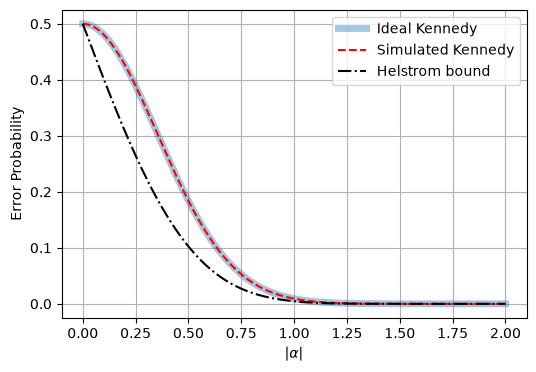

In [50]:
alphas=np.linspace(0,2,200)
P_kennedy_s=[error_ke(N,i) for i in alphas]


# 2. Ideal Kennedy
P_kennedy = 0.5 * np.exp(-4 * np.abs(alphas)**2)

# 3. Helstrom bound
overlap_squared = np.exp(-4 * np.abs(alphas)**2)
P_helstrom = 0.5 * (1 - np.sqrt(1 - overlap_squared))

# --- Simplest Plot Structure ---
fig, ax = plt.subplots(figsize=(6, 4))

# 투명도(alpha=0.4)와 두께(linewidth=5)를 줘서 바탕에 깔아줌
ax.plot(alphas, P_kennedy, label="Ideal Kennedy", linewidth=5, alpha=0.4)

# 그 위에 얇은 점선('--')을 얹어서 두 그래프가 겹쳐서 같이 간다는 걸 증명
ax.plot(alphas, P_kennedy_s, '--', label="Simulated Kennedy", color='red')

# 헬스트롬 바운드
ax.plot(alphas, P_helstrom, '-.', label="Helstrom bound", color='black')

ax.set_xlabel(r"$|\alpha|$")
ax.set_ylabel("Error Probability")
ax.grid(True)
ax.legend()

plt.show()

In [44]:
def beta_opt(a):
    if a > 3.0:                       # b* - a < 1 ULP, 구분 불가
        return a
    g = lambda b: 4*a*b - np.log((b + a)/(b - a))
    lo = np.nextafter(a, np.inf)      # 표현 가능한 a 바로 다음 수
    return brentq(g, lo, 3*a + 1)

In [46]:
print(beta_opt(0.7))

0.8450050222108977


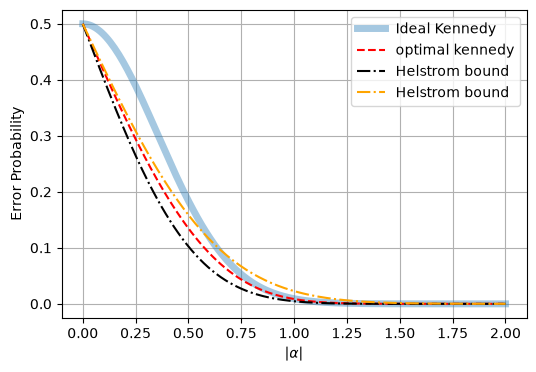

In [ ]:
alphas=np.linspace(0,2,200)

# 2. Ideal Kennedy
P_kennedy = 0.5 * np.exp(-4 * np.abs(alphas)**2)

# 3. Helstrom bound
overlap_squared = np.exp(-4 * np.abs(alphas)**2)
P_helstrom = 0.5 * (1 - np.sqrt(1 - overlap_squared))

#optimal kennedy
P_kennedy_opt=[error_ke(N,i,beta_opt(i)) for i in alphas]

#homodyne
P_hom_theory = 0.5 * erfc(np.sqrt(2) * np.abs(alphas))

# --- Simplest Plot Structure ---
fig, ax = plt.subplots(figsize=(6, 4))

# 투명도(alpha=0.4)와 두께(linewidth=5)를 줘서 바탕에 깔아줌
ax.plot(alphas, P_kennedy, label="Ideal Kennedy", linewidth=5, alpha=0.4)

# 그 위에 얇은 점선('--')을 얹어서 두 그래프가 겹쳐서 같이 간다는 걸 증명
ax.plot(alphas,P_kennedy_opt , '--', label="optimal kennedy", color='red')

# 헬스트롬 바운드
ax.plot(alphas, P_helstrom, '-.', label="Helstrom bound", color='black')

#호모다인
ax.plot(alphas, P_hom_theory, '-.', label="Homodyne", color='orange')

ax.set_xlabel(r"$|\alpha|$")
ax.set_ylabel("Error Probability")
ax.grid(True)
ax.legend()

plt.show()

In [ ]:
#making circuit
N,alpha= 30,0.5
a_p=q.coherent(N,alpha) #a_p is positive alpha
a_n=q.coherent(N,-alpha) #a_n is negative alpha


